### Multiclass image classification

> *We've just been through a bunch of the following steps with a binary classification problem (pizza vs steak), now we're going to step things up a notch with 10 classes of food (multiclass classification)*

1. Become one with the data
2. Preprocess the data (get it ready for a model)
3. Create a model (start with a baseline)
4. Fit the model (overfit it to make sure it works)
5. Evaluate the model
6. Adjust different hyperparameters and improve the model (try to beat the baseline/reduce overfitting)
7. Repeat until satisfied

In [1]:
import tensorflow as tf

2026-05-29 18:37:19.841916: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### 1. Importing and becoming one with the data

In [ ]:
import zipfile

!curl -o ../../data/10_food_classes_all_data.zip https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  495M  100  495M    0     0  4589k      0  0:01:50  0:01:50 --:--:-- 4678k6k      0  0:02:52  0:00:05  0:02:47 3468k:01:55  0:00:38  0:01:17 4620k  0  4401k      0  0:01:55  0:00:40  0:01:15 4697k    0  4514k      0  0:01:52  0:01:11  0:00:41 4655k  0  0:01:51  0:01:13  0:00:38 4688k      0  0:01:51  0:01:22  0:00:29 4697k70k      0  0:01:50  0:01:35  0:00:15 4785k


In [11]:
# unzip our data
zip_ref = zipfile.ZipFile('../../data/10_food_classes_all_data.zip', 'r')
zip_ref.extractall()
zip_ref.close()

In [13]:
# walk through 10 classes of food images data
import os

for dirpath, dirname, filename in os.walk('10_food_classes_all_data'):
    print(f'There are {len(dirname)} directories and {len(filename)} images in {dirpath}')

There are 2 directories and 0 images in 10_food_classes_all_data
There are 10 directories and 0 images in 10_food_classes_all_data/test
There are 0 directories and 250 images in 10_food_classes_all_data/test/ice_cream
There are 0 directories and 250 images in 10_food_classes_all_data/test/chicken_curry
There are 0 directories and 250 images in 10_food_classes_all_data/test/steak
There are 0 directories and 250 images in 10_food_classes_all_data/test/sushi
There are 0 directories and 250 images in 10_food_classes_all_data/test/chicken_wings
There are 0 directories and 250 images in 10_food_classes_all_data/test/grilled_salmon
There are 0 directories and 250 images in 10_food_classes_all_data/test/hamburger
There are 0 directories and 250 images in 10_food_classes_all_data/test/pizza
There are 0 directories and 250 images in 10_food_classes_all_data/test/ramen
There are 0 directories and 250 images in 10_food_classes_all_data/test/fried_rice
There are 10 directories and 0 images in 10_fo

In [15]:
# setup train and test directories
train_dir = '10_food_classes_all_data/train/'
test_dir = '10_food_classes_all_data/test/'

In [16]:
# let's get the class names
import pathlib
import numpy as np

data_dir = pathlib.Path(train_dir)
class_names = np.array(sorted([item.name for item in data_dir.glob('*')]))

print(class_names)

['chicken_curry' 'chicken_wings' 'fried_rice' 'grilled_salmon' 'hamburger'
 'ice_cream' 'pizza' 'ramen' 'steak' 'sushi']


In [17]:
# visualize visulaize visualize
# Lets visualize our images
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

def view_random_image(target_dir, target_class):
    '''Setup the target directories (we'll view the images from here)'''
    target_folder = target_dir+target_class
    
    # get a random image path
    random_image = random.sample(os.listdir(target_folder), 1)
    print(random_image)
    
    # read in the image and plot it 
    img = mpimg.imread(target_folder + "/" + random_image[0])
    plt.imshow(img)
    plt.title(target_class)
    plt.axis("off")
    
    print(f"Image shape: {img.shape}") # shwo the shape of the image
    
    return img

['748440.jpg']
Image shape: (512, 512, 3)


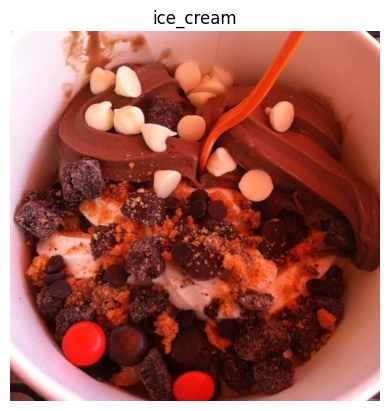

In [32]:
# view a random image from the training dataset
img = view_random_image(target_dir=train_dir,
                        target_class=random.choice(class_names))

### 2. Preprocess the data

In [33]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# rescale 
train_datagen = ImageDataGenerator(rescale=1/255.)
test_datagen = ImageDataGenerator(rescale=1/255.)

# load data in from directories and turn it into batches
train_data = train_datagen.flow_from_directory(train_dir,
                                               target_size=(224, 224),
                                               batch_size=32,
                                               class_mode='categorical')

test_data = test_datagen.flow_from_directory(test_dir,
                                               target_size=(224, 224),
                                               batch_size=32,
                                               class_mode='categorical')

Found 7500 images belonging to 10 classes.
Found 2500 images belonging to 10 classes.


### 3. Create the model

In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Activation

# create our model
model = Sequential([
    Conv2D(10, 3, input_shape=(224, 224, 3)),
    Activation(activation='relu'),
    Conv2D(10, 3, activation='relu'),
    MaxPool2D(),
    Conv2D(10, 3, activation='relu'),
    Conv2D(10, 3, activation='relu'),
    MaxPool2D(),
    Flatten(),
    Dense(10, activation='softmax')    
])

# compile the model
model.compile(loss='categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(),
              metrics=['accuracy'])

/Users/spy/Desktop/dl-journey/.venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
# fit the model
history = model.fit(train_data,
                    epochs=5,
                    steps_per_epoch=len(train_data),
                    validation_data=test_data,
                    validation_steps=len(test_data))

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 162s 680ms/step - accuracy: 0.2320 - loss: 2.1233 - val_accuracy: 0.3004 - val_loss: 1.9635
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 164s 696ms/step - accuracy: 0.3500 - loss: 1.8894 - val_accuracy: 0.3492 - val_loss: 1.8965
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 176s 751ms/step - accuracy: 0.4567 - loss: 1.6109 - val_accuracy: 0.3304 - val_loss: 1.9401
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 190s 809ms/step - accuracy: 0.6767 - loss: 0.9949 - val_accuracy: 0.3152 - val_loss: 2.2873
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 314s 1s/step - accuracy: 0.8936 - loss: 0.3550 - val_accuracy: 0.3040 - val_loss: 3.1913


### 4. Evaluate the model

In [37]:
model.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 146ms/step - accuracy: 0.3040 - loss: 3.1913


[3.1912529468536377, 0.30399999022483826]

In [38]:
# check out the model loss curves
# plot validation and training curves seperately
def plot_loss_curves(history):
    ''' 
    Returns seperate loss curves for traning and validation metrics.
    '''
    loss = history.history['loss']
    val_loss = history.history["val_loss"]
    
    accuracy = history.history['accuracy']
    val_accuracy = history.history["val_accuracy"]
    
    epochs = range(len(history.history["loss"])) # how many epochs did we run for
    
    # plot loss
    plt.plot(epochs, loss, label="training loss")
    plt.plot(epochs, val_loss, label="val_loss")
    plt.xlabel("epochs")
    plt.title("loss")
    plt.legend()
    
    # plot accuracy
    plt.figure()
    plt.plot(epochs, accuracy, label="training accuracy")
    plt.plot(epochs, val_accuracy, label="val_accuracy")
    plt.xlabel("epochs")
    plt.title("accuracy")
    plt.legend()

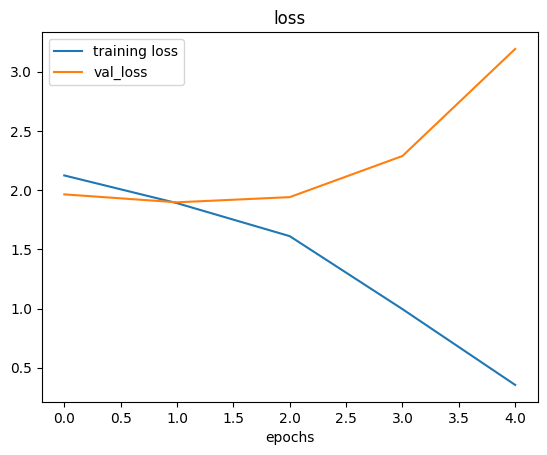

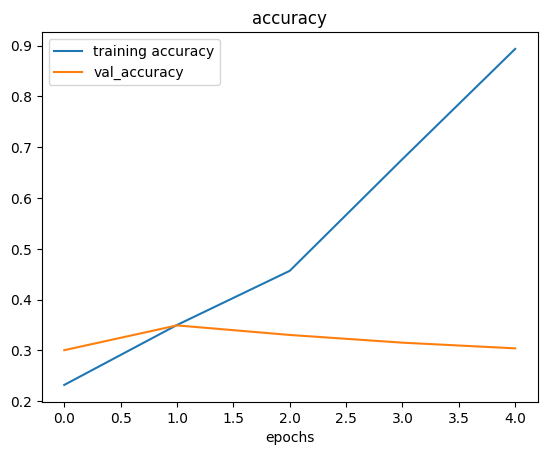

In [39]:
plot_loss_curves(history)

What do these loss curves tell us?

Well... it seems our model is **overfitiing** the training set quiet badly... in other words its getting great results on trining data but fails to generalize well to unseen data and performs poorly on test dataset.

### 5. Adjust the model Hyperparameter (to beat the baseline/reduce overfitting)

Due to its performance on the training data, it's clear our model is learning something...

However, it's not generalizing well to unseen data (overfitting)

Let's try and fix overfitting by...

* **Get more data** - having more data gives a model more opportunity to learn diverse patterns...
* **Simplify the model** - if our current model is overfitting the data, it means it may be too complicated model, one way to simplify a model is to: reduce # of layers or reduce # hidden units in layers.
* **Use data augmentation** - data augmentation manipulates the training data in such a way to ad moree diversity to it (without altering the original data).
* **Use transfer learning** - transfer learning leverages the patterns another model has learned on similar data to your own and aloows you to use those patterns on your own dataset.

In [41]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 222, 222, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │       280,910 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 851,762 (3.25 MB)

 Trainable params: 283,920 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 567,842 (2.17 MB)

In [42]:
# simplify the model first
# let's try to remove 2 convolutional layers
model_1 = Sequential([
    Conv2D(10, 3, input_shape=(224, 224, 3)),
    Activation(activation='relu'),
    MaxPool2D(),
    Conv2D(10, 3, activation='relu'),
    MaxPool2D(),
    Flatten(),
    Dense(10, activation='softmax')
])

# compile the model
model_1.compile(loss='categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(),
              metrics=['accuracy'])

/Users/spy/Desktop/dl-journey/.venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [43]:
model_1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 222, 222, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 29160)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │       291,610 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 292,800 (1.12 MB)

 Trainable params: 292,800 (1.12 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
# fit the model
history_1 = model_1.fit(train_data,
                    epochs=5,
                    steps_per_epoch=len(train_data),
                    validation_data=test_data,
                    validation_steps=len(test_data))

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 72s 300ms/step - accuracy: 0.2360 - loss: 2.1224 - val_accuracy: 0.3064 - val_loss: 2.0248
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 71s 302ms/step - accuracy: 0.4091 - loss: 1.7550 - val_accuracy: 0.3544 - val_loss: 1.8571
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 72s 304ms/step - accuracy: 0.5476 - loss: 1.3894 - val_accuracy: 0.3164 - val_loss: 2.0084
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 73s 312ms/step - accuracy: 0.7005 - loss: 0.9568 - val_accuracy: 0.3076 - val_loss: 2.2589
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 83s 352ms/step - accuracy: 0.8323 - loss: 0.5696 - val_accuracy: 0.3036 - val_loss: 2.7744


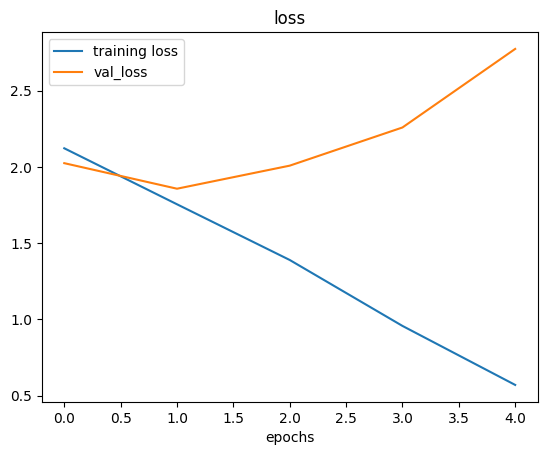

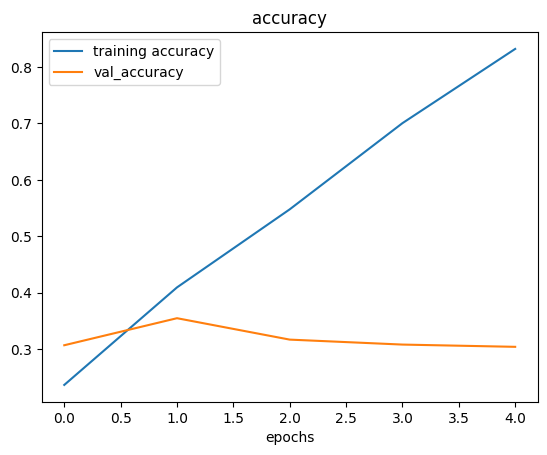

In [45]:
# check out the loss curves
plot_loss_curves(history_1)

Looks like our "Simplify the model" experiment didin't work... the accuracy went down and overfittin g continue.

How about try data augmentation

### Trying to reduce overfitting with data augmentation

Lets's try and improve our model's result by using augmented training data...

Ideally we want to:
* Reduce overfitting (get the training and validation loss curves closer)
* Improve validation accuracy

In [47]:
# create an augmented data generator instance
train_datagen_augmented = ImageDataGenerator(rescale=1/255.,
                                          rotation_range=0.2,
                                          width_shift_range=0.2,
                                          height_shift_range=0.2,
                                          zoom_range=0.2,
                                          horizontal_flip=True)

train_data_augmented = train_datagen_augmented.flow_from_directory(train_dir,
                                                                   target_size=(224,224),
                                                                   batch_size=32,
                                                                   class_mode='categorical')
                                                                   

Found 7500 images belonging to 10 classes.


In [48]:
# lets create another model but this time fit on augmented data
model_2 = tf.keras.models.clone_model(model)

# compile the cloned model (using the same setup as previous models)
model_2.compile(loss='categorical_crossentropy',
                optimizer=tf.keras.optimizers.Adam(),
                metrics=['accuracy'])

In [49]:
model_2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 222, 222, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │       280,910 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 283,920 (1.08 MB)

 Trainable params: 283,920 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

In [50]:
# fit the model
history_2 = model_2.fit(train_data_augmented,
                    epochs=5,
                    steps_per_epoch=len(train_data_augmented),
                    validation_data=test_data,
                    validation_steps=len(test_data))

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 175s 739ms/step - accuracy: 0.2204 - loss: 2.1442 - val_accuracy: 0.2656 - val_loss: 2.0067
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 182s 775ms/step - accuracy: 0.2763 - loss: 2.0376 - val_accuracy: 0.3348 - val_loss: 1.9067
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 198s 839ms/step - accuracy: 0.3105 - loss: 1.9806 - val_accuracy: 0.3668 - val_loss: 1.8179
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 201s 855ms/step - accuracy: 0.3440 - loss: 1.9116 - val_accuracy: 0.3976 - val_loss: 1.7420
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 259s 1s/step - accuracy: 0.3412 - loss: 1.8853 - val_accuracy: 0.4152 - val_loss: 1.7540


In [51]:
model_2.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 145ms/step - accuracy: 0.4152 - loss: 1.7540


[1.7540197372436523, 0.41519999504089355]

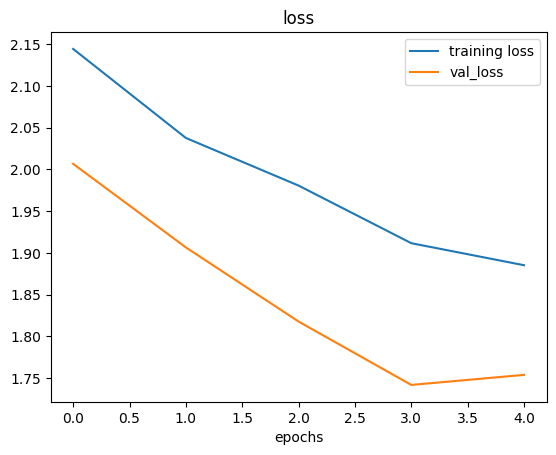

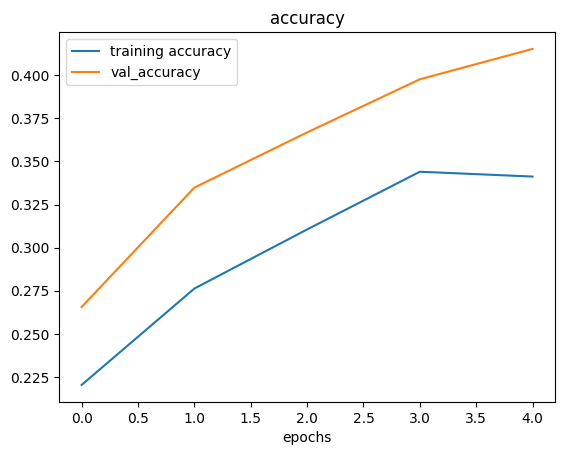

In [52]:
# plot the loss curves
plot_loss_curves(history_2)

### Repeat until satisfied

We could keep going here... continuously tring to bring our loss curves closer together and trying to improve the validation/test accuracy.

How?

By running lots of experiments, namely:
- restructuring our model's architecture (increasing layers/hidden units)
- adjust the learning rates
- try different methods of data augmentation (adjust the hyperparameters in our ImageDataGenerator instances)
- training for longer (e.g for 10 epochs instead of 5)
- try **transfer learning**

### Making prediction with our trained model

Let's use our trained model to make some predictions on our own custom Images!

In [53]:
class_names

array(['chicken_curry', 'chicken_wings', 'fried_rice', 'grilled_salmon',
       'hamburger', 'ice_cream', 'pizza', 'ramen', 'steak', 'sushi'],
      dtype='<U14')

In [55]:
# download some custom images
!curl -L https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/03-sushi.jpeg -o 03-sushi.jpeg

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1684k  100 1684k    0     0  4045k      0 --:--:-- --:--:-- --:--:--     0-- 4049k


In [56]:
# amke a predict
# create a function to import an image and resize it to be able to be use with our model
def load_and_prep_image(filename, img_shape=224):
    ''' 
    Reads the image from filename, turns it into a tensor and reshape it to 
    (img_shape, img_shape, color_channel).
    '''
    img = tf.io.read_file(filename)
    
    # decode the read file into tensor
    img = tf.image.decode_image(img)
    
    # resize the image
    img = tf.image.resize(img, size=[img_shape, img_shape])
    
    # rescale the image (get all values between 0 & 1)
    img = img/255.
    
    return img

# function to predict and plot
def pred_and_plot(model, filename, class_names=class_names):
    ''' 
    Imports and image located at filename, makes a prediction with model and plots the image with the
    predicted class as the title.
    '''
    # Import the target image abd prprocess it
    img = load_and_prep_image(filename)
    
    # make a prediction
    pred = model.predict(tf.expand_dims(img, axis=0))
    
    # Add logic for multiclass
    if len(pred[0]) > 1:
        pred_class = class_names[tf.argmax(pred[0])]
    else:
        pred_class = class_names[int(tf.round(pred[0]))]

    
    # plot the image and predicted class
    plt.imshow(img)
    plt.title(f"Prediction: {pred_class}")
    plt.axis(False);

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


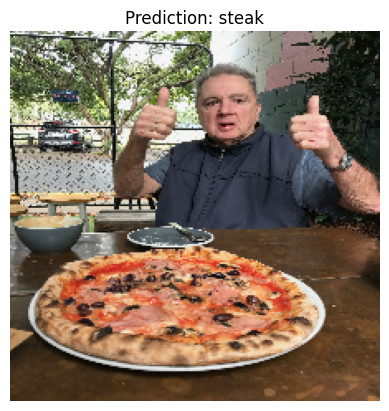

In [60]:
# making some prediction
pred_and_plot(model=model_2,
              filename='03-pizza-dad.jpeg',
              class_names=class_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


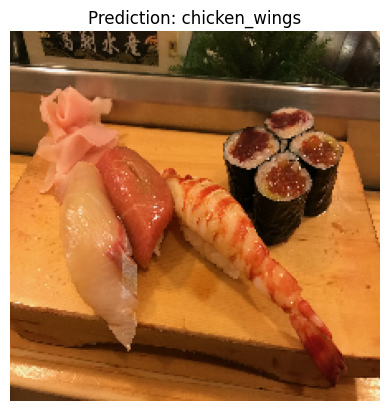

In [61]:
pred_and_plot(model=model_2,
              filename='03-sushi.jpeg',
              class_names=class_names)

### Savingand loading our model

In [64]:
# save a model
model_2.save('../../assets/saved_trained_model_2.keras')

In [65]:
# load the trained model and evaluate
loaded_model_2 = tf.keras.models.load_model('../../assets/saved_trained_model_2.keras')
loaded_model_2.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 158ms/step - accuracy: 0.4152 - loss: 1.7540


[1.7540199756622314, 0.41519999504089355]

In [66]:
# compare tge loaded model with our original model
model_2.evaluate(test_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 153ms/step - accuracy: 0.4152 - loss: 1.7540


[1.7540197372436523, 0.41519999504089355]

## Transfer Learning